In [7]:
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.ensemble import GradientBoostingClassifier

from sklearn.metrics import classification_report, accuracy_score

In [8]:
df = pd.read_csv('Dataset/archive/churn.csv')

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB


In [10]:
df.columns

Index(['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography',
       'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited'],
      dtype='object')

In [11]:
df

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,15606229,Obijiaku,771,France,Male,39,5,0.00,2,1,0,96270.64,0
9996,9997,15569892,Johnstone,516,France,Male,35,10,57369.61,1,1,1,101699.77,0
9997,9998,15584532,Liu,709,France,Female,36,7,0.00,1,0,1,42085.58,1
9998,9999,15682355,Sabbatini,772,Germany,Male,42,3,75075.31,2,1,0,92888.52,1


In [12]:
Label_encoder = LabelEncoder()

df['Gender'] = Label_encoder.fit_transform(df['Gender'])

In [13]:
df['Gender'].value_counts()

Gender
1    5457
0    4543
Name: count, dtype: int64

In [14]:
ohe = OneHotEncoder(sparse_output=False) 

geo_encoded = ohe.fit_transform(df[['Geography']])

In [15]:
geo_encoded

array([[1., 0., 0.],
       [0., 0., 1.],
       [1., 0., 0.],
       ...,
       [1., 0., 0.],
       [0., 1., 0.],
       [1., 0., 0.]])

In [16]:
ohe.get_feature_names_out()

array(['Geography_France', 'Geography_Germany', 'Geography_Spain'],
      dtype=object)

In [17]:
geo_df = pd.DataFrame(geo_encoded, columns=ohe.get_feature_names_out())

In [18]:
df = pd.concat([df, geo_df], axis=1)

In [19]:
df

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_France,Geography_Germany,Geography_Spain
0,1,15634602,Hargrave,619,France,0,42,2,0.00,1,1,1,101348.88,1,1.0,0.0,0.0
1,2,15647311,Hill,608,Spain,0,41,1,83807.86,1,0,1,112542.58,0,0.0,0.0,1.0
2,3,15619304,Onio,502,France,0,42,8,159660.80,3,1,0,113931.57,1,1.0,0.0,0.0
3,4,15701354,Boni,699,France,0,39,1,0.00,2,0,0,93826.63,0,1.0,0.0,0.0
4,5,15737888,Mitchell,850,Spain,0,43,2,125510.82,1,1,1,79084.10,0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,9996,15606229,Obijiaku,771,France,1,39,5,0.00,2,1,0,96270.64,0,1.0,0.0,0.0
9996,9997,15569892,Johnstone,516,France,1,35,10,57369.61,1,1,1,101699.77,0,1.0,0.0,0.0
9997,9998,15584532,Liu,709,France,0,36,7,0.00,1,0,1,42085.58,1,1.0,0.0,0.0
9998,9999,15682355,Sabbatini,772,Germany,1,42,3,75075.31,2,1,0,92888.52,1,0.0,1.0,0.0


In [20]:
df.columns

Index(['RowNumber', 'CustomerId', 'Surname', 'CreditScore', 'Geography',
       'Gender', 'Age', 'Tenure', 'Balance', 'NumOfProducts', 'HasCrCard',
       'IsActiveMember', 'EstimatedSalary', 'Exited', 'Geography_France',
       'Geography_Germany', 'Geography_Spain'],
      dtype='object')

In [21]:
X = df.drop(['RowNumber', 'CustomerId', 'Surname', 'Geography', 'Exited'], axis=1)
Y = df['Exited']

In [22]:
X_train, X_test, y_train, y_test = train_test_split(X, Y, test_size=0.3, random_state=42)

In [122]:
gbrt = GradientBoostingClassifier(learning_rate=0.01, n_estimators=1000)

In [123]:
gbrt.fit(X_train, y_train)

GradientBoostingClassifier(learning_rate=0.01, n_estimators=1000)

In [124]:
def evaluate_model(model, X_test, y_test, model_name):
    y_pred = model.predict(X_test)

    print(f"\n{model_name}")
    print("Accuracy:", accuracy_score(y_test, y_pred))
    print(classification_report(y_test, y_pred))

In [126]:
evaluate_model(gbrt, X_train, y_train, "GradientBoosting_train_Accuracy")
evaluate_model(gbrt, X_test, y_test, "GradientBoosting_test_Accuracy")


GradientBoosting_train_Accuracy
Accuracy: 0.8718571428571429
              precision    recall  f1-score   support

           0       0.88      0.97      0.92      5547
           1       0.81      0.50      0.62      1453

    accuracy                           0.87      7000
   macro avg       0.85      0.73      0.77      7000
weighted avg       0.87      0.87      0.86      7000


GradientBoosting_test_Accuracy
Accuracy: 0.8706666666666667
              precision    recall  f1-score   support

           0       0.88      0.97      0.92      2416
           1       0.77      0.48      0.59       584

    accuracy                           0.87      3000
   macro avg       0.83      0.72      0.76      3000
weighted avg       0.86      0.87      0.86      3000



In [127]:
import matplotlib.pyplot as plt

In [128]:
import numpy as np

In [129]:
gbrt.feature_importances_

array([0.01944631, 0.01354169, 0.39099395, 0.00426763, 0.07663706,
       0.30369811, 0.00082024, 0.11591052, 0.02139609, 0.00249773,
       0.05030965, 0.00048102])

In [130]:
columns_ = np.array(X.columns)

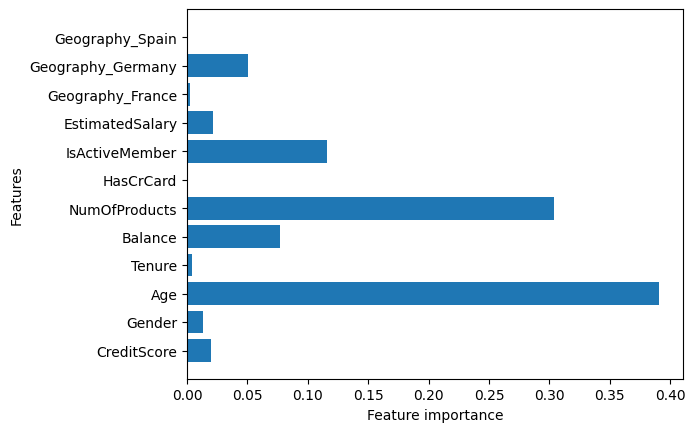

In [131]:
plt.barh(columns_, gbrt.feature_importances_, align='center')
plt.xlabel('Feature importance')
plt.ylabel('Features')

plt.show()

In [132]:
X_test

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Geography_France,Geography_Germany,Geography_Spain
6252,596,1,32,3,96709.07,2,0,0,41788.37,0.0,1.0,0.0
4684,623,1,43,1,0.00,2,1,1,146379.30,1.0,0.0,0.0
1731,601,0,44,4,0.00,2,1,0,58561.31,0.0,0.0,1.0
4742,506,1,59,8,119152.10,2,1,1,170679.74,0.0,1.0,0.0
4521,560,0,27,7,124995.98,1,1,1,114669.79,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...
8014,731,0,39,2,126816.18,1,1,1,74850.93,0.0,0.0,1.0
1074,535,0,31,7,111855.04,2,1,1,36278.89,1.0,0.0,0.0
3063,609,1,32,7,71872.19,1,1,1,151924.90,1.0,0.0,0.0
6487,580,1,31,2,0.00,2,0,1,64014.24,1.0,0.0,0.0


Test data:

Credit Score: 502    
Gender: Female    
Age: 42  	  
Tenure: 8    	
Balance: 159660.80    	
Num_preducts: 3  	  
Has_creditcard: 1    	
IsActive: 0  	  
EstimatedSalary: 113931.57    	
Geography: France    

----------------  
Exited  ---> 1 (churn)    
----------------    

In [117]:
credit_score = int(input('Enter CreditScore: '))  # 596

# I have label encoded Gender
gender = input("Enter Gender")  # Male/Female
gender = Label_encoder.transform([gender])[0]

age = int(input('Enter Age')) # 32

Tenure = float(input("Enter Tenure"))  # 3

Balance = float(input("Enter Balance:"))  # 96709.07

Num_products = int(input("Enter Num products: "))  # 2

has_credit_card = int(input("Has credit card (Enter 0/1): ")) # 0

is_active = int(input("Is active (0/1): "))  # 0

Estimated_salary = float(input("Enter Estimated salary: ")) # 41788.37

geography = input("Enter Geography [France, Germany, Spain]")  # Germany
geography = ohe.transform([[geography]])[0]


churn = gbrt.predict([[credit_score, gender, age, Tenure, Balance, Num_products, has_credit_card, is_active, Estimated_salary, geography[0], geography[1], geography[2]]])

print("churn: ", churn)

churn:  [1]


c:\Users\ABC\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but OneHotEncoder was fitted with feature names
  warnings.warn(
c:\Users\ABC\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but GradientBoostingClassifier was fitted with feature names
  warnings.warn(


In [133]:
import joblib

In [134]:
joblib.dump(gbrt, 'churn_pred_gbrt_model.pkl')

['churn_pred_gbrt_model.pkl']

In [135]:
joblib.dump(Label_encoder, 'gender_label_encoder.pkl')

['gender_label_encoder.pkl']

In [136]:
joblib.dump(ohe, 'geography_ohe.pkl')

['geography_ohe.pkl']